In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
excel_file = 'Cleaned_Customers_Dataset.xlsx'
df = pd.read_excel(excel_file)

df['spending_rank'] = df['total_spending'].rank(ascending=False)
df['recency_rank'] = df['last_purchase_days'].rank(ascending=True)
df['purchase_rank'] = df['purchase_count'].rank(ascending=False)

top_spenders = df.sort_values(by='total_spending', ascending=False).head(10)
print(top_spenders[['customer_id', 'first_name', 'city', 'membership_tier', 'purchase_count', 'total_spending', 'last_purchase_days', 'satisfaction_score']])

    customer_id first_name     city membership_tier  purchase_count  \
43         1044       Mina   Shiraz            Gold              33   
56         1057     Maryam    Ahvaz          Bronze              31   
11         1012      Arash  Mashhad            Gold              27   
8          1009      Kimia    Karaj          Silver              34   
58         1059        Ali  Isfahan            Gold              31   
9          1010      Arash    Karaj          Silver              19   
49         1050       Reza  Mashhad          Bronze              30   
3          1004       Sina  Mashhad            Gold              23   
54         1055       Mina    Rasht          Bronze              19   
34         1035      Arash   Tabriz          Bronze              17   

    total_spending  last_purchase_days  satisfaction_score  
43        14354.34                 165                   2  
56        13532.74                  82                   4  
11        11731.50                 

In [16]:
selected_10 = top_spenders.head(10).copy()
print(selected_10[['customer_id', 'first_name', 'city', 'membership_tier', 'purchase_count', 'total_spending', 'last_purchase_days', 'satisfaction_score']])

    customer_id first_name     city membership_tier  purchase_count  \
43         1044       Mina   Shiraz            Gold              33   
56         1057     Maryam    Ahvaz          Bronze              31   
11         1012      Arash  Mashhad            Gold              27   
8          1009      Kimia    Karaj          Silver              34   
58         1059        Ali  Isfahan            Gold              31   
9          1010      Arash    Karaj          Silver              19   
49         1050       Reza  Mashhad          Bronze              30   
3          1004       Sina  Mashhad            Gold              23   
54         1055       Mina    Rasht          Bronze              19   
34         1035      Arash   Tabriz          Bronze              17   

    total_spending  last_purchase_days  satisfaction_score  
43        14354.34                 165                   2  
56        13532.74                  82                   4  
11        11731.50                 

In [17]:
vips = df[df['membership_tier'] == 'VIP'].sort_values(by='total_spending', ascending=False)
print("VIP Customers:")
print(vips[['customer_id', 'first_name', 'city', 'membership_tier', 'purchase_count', 'total_spending', 'last_purchase_days', 'satisfaction_score']])

df['recency_score'] = pd.qcut(df['last_purchase_days'], 5, labels=[5, 4, 3, 2, 1]).astype(int)
df['frequency_score'] = pd.qcut(df['purchase_count'], 5, labels=[1, 2, 3, 4, 5]).astype(int)
df['monetary_score'] = pd.qcut(df['total_spending'], 5, labels=[1, 2, 3, 4, 5]).astype(int)

df['composite_score'] = df['monetary_score']*0.5 + df['frequency_score']*0.3 + df['recency_score']*0.2

final_10 = df.sort_values(by=['total_spending'], ascending=False).head(10).copy()

for idx, row in final_10.iterrows():
    print(f"{row['customer_id']} | {row['first_name']} | {row['city']} | {row['membership_tier']} | purchase_count: {row['purchase_count']} | total_spending: {row['total_spending']:,.2f} | last_purchase_days: {row['last_purchase_days']} | satisfaction_score: {row['satisfaction_score']}")

VIP Customers:
    customer_id first_name     city membership_tier  purchase_count  \
32         1033       Neda   Tabriz             VIP              24   
45         1046     Maryam   Tabriz             VIP              15   
29         1030       Sina  Mashhad             VIP              26   
13         1014       Reza   Tabriz             VIP              31   
16         1017      Parsa    Ahvaz             VIP              30   
6          1007       Reza    Rasht             VIP              29   
33         1034     Maryam   Tabriz             VIP              29   
0          1001       Reza    Karaj             VIP              17   
17         1018        Ali   Shiraz             VIP              18   
47         1048       Sina   Tabriz             VIP              12   
7          1008       Reza    Rasht             VIP               3   
35         1036       Sina    Karaj             VIP               9   
42         1043      Kimia    Ahvaz             VIP           

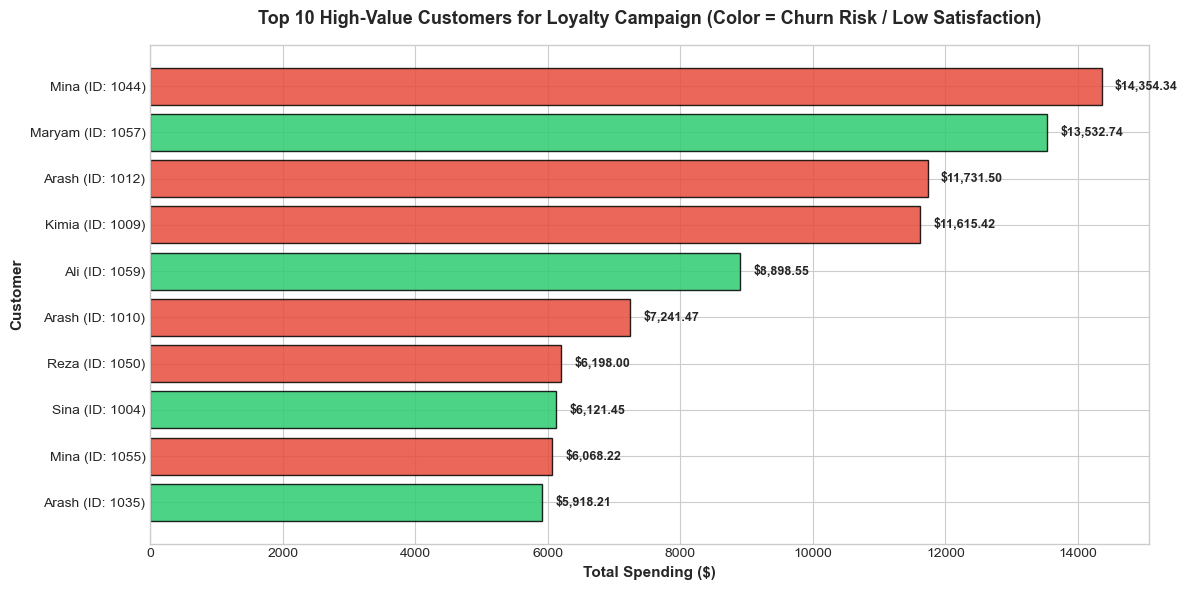

In [20]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 6))

# Sort for plotting
plot_df = final_10.sort_values(by='total_spending', ascending=True)

# Color coding based on risk/satisfaction
colors = ['#e74c3c' if score <= 2 else '#2ecc71' for score in plot_df['satisfaction_score']]

bars = ax.barh(plot_df['first_name'] + " (ID: " + plot_df['customer_id'].astype(str) + ")", 
               plot_df['total_spending'], color=colors, alpha=0.85, edgecolor='black')

ax.set_title('Top 10 High-Value Customers for Loyalty Campaign (Color = Churn Risk / Low Satisfaction)', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Total Spending ($)', fontsize=11, fontweight='bold')
ax.set_ylabel('Customer', fontsize=11, fontweight='bold')

# Annotate bars with values
for bar in bars:
    width = bar.get_width()
    ax.text(width + 200, bar.get_y() + bar.get_height()/2, f'${width:,.2f}', 
            va='center', ha='left', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()
plt.close()